1. Are these layers only on drive or also on GEE/Geoserver? 

2. Do style files remain same as the block level style files for Pan India datasets as well? 

3. All layers to be generated or only few? 

In [218]:
!pip install earthengine-api


Defaulting to user installation because normal site-packages is not writeable


In [261]:
import rasterio
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from shapely.geometry import Polygon
import requests
import xml.etree.ElementTree as ET
from io import BytesIO
import pystac
from pystac.extensions.table import TableExtension
from pystac import Asset, MediaType
from pystac.extensions.classification import ClassificationExtension, Classification
from pystac.extensions.raster import RasterExtension,RasterBand
from pystac.extensions.projection import ProjectionExtension
import datetime
import ee
ee.Initialize(project='ee-corestackdev')

In [220]:

## WRIrestoration.tiff (71MB)
#direct_download_url = 'https://drive.google.com/uc?export=download&id=1JsV9ZDu2680-bV596EasCJHO2ndHLk2s'

##Stream_order_raster.tiff (250 MB)
#direct_download_url= 'https://drive.google.com/uc?export=download&id=1U9CE-B48k8-syATpqVowWEx7kTQM54NQ'
#cog_url = f'/vsicurl/{direct_download_url}'


##assets
#asset_id='projects/corestack-datasets/assets/datasets/Stream_Order_Raster_India'
asset_id='projects/corestack-datasets/assets/datasets/WRI/LandscapeRestorationOpportunities'

image = ee.Image(asset_id)
image_info = image.getInfo()

In [221]:
image_info

{'type': 'Image',
 'bands': [{'id': 'b1',
   'data_type': {'type': 'PixelType',
    'precision': 'int',
    'min': 0,
    'max': 255},
   'dimensions': [51122, 58070],
   'crs': 'EPSG:32643',
   'crs_transform': [60, 0, -261255, 0, -60, 4246151]}],
 'version': 1752832499951494,
 'id': 'projects/corestack-datasets/assets/datasets/WRI/LandscapeRestorationOpportunities',
 'properties': {'system:footprint': {'type': 'LinearRing',
   'coordinates': [[100.20771182205205, 35.59778380646151],
    [90.22083511444218, 37.36844862949585],
    [77.27407489048859, 38.34302126171353],
    [66.33199027788123, 38.04259234612545],
    [67.05807024455329, 30.754874636141228],
    [67.58811730285349, 22.961051759810456],
    [67.92938101457304, 15.151948877147923],
    [68.12593897625494, 6.843599263554259],
    [95.41833663170242, 6.46072668342524],
    [95.6343778102072, 10.379594911660046],
    [95.93536093222171, 14.06033310544447],
    [96.33747208968617, 17.731384904647403],
    [96.84941936876834,

In [222]:
crs = image_info['bands'][0]['crs']
transform = image_info['bands'][0]['crs_transform']
width = image_info['bands'][0]['dimensions'][0]
height = image_info['bands'][0]['dimensions'][1]
bands = len(image_info['bands'])

In [223]:
print("CRS:", crs)
print("Bounds:", bbox)
#print("Pixel size (GSD):", (gsd_x, gsd_y))
print("Width x Height:", width, "x", height)
print("Bands:", bands)

CRS: EPSG:32643
Bounds: [66.33178024244229, 6.460324197273955, 100.20778859575992, 38.36471016500606]
Width x Height: 51122 x 58070
Bands: 1


In [224]:

item_id = 'Landscape-Restoration-WRI'

raster_item = pystac.Item(id=item_id,
                      geometry=10,
                      bbox=bbox,
                      datetime=datetime.datetime.now(datetime.timezone.utc),
                      properties={
                        #   title
                        # description
                          # "gsd": gsd, #adding this in raster extension 
                      })

In [225]:
proj_ext = ProjectionExtension.ext(raster_item, add_if_missing=True)
proj_ext.epsg = crs
#proj_ext.shape = [shape[0], shape[1]]

In [226]:
raster_item

<Item id=Landscape-Restoration-WRI>

In [227]:
raster_item.add_asset("data", Asset(
    href=asset_id,
    media_type=MediaType.GEOTIFF,
    roles=["data"],
    title="Raster Layer"
))

In [228]:
raster_ext = RasterExtension.ext(raster_item.assets["data"], add_if_missing=True)
raster_band = RasterBand.create(
    #data_type=data_type, 
    spatial_resolution=10,
    # nodata=nodata
)
raster_ext.bands = [raster_band]

In [229]:
github_style_file='https://raw.githubusercontent.com/core-stack-org/QGIS-Styles/main/Restoration/Restoration_style.qml'

In [230]:
def parse_raster_style_file(github_style_file):

    try:
        response = requests.get(github_style_file, verify=False)
        response.raise_for_status()
        
    
        tree = ET.parse(BytesIO(response.content))
        root = tree.getroot()
        classes = []

        for entry in root.findall(".//paletteEntry"):
            class_info = {}
            for attr_key, attr_value in entry.attrib.items():
                if attr_key == "value":
                    try:
                        class_info[attr_key] = int(attr_value)
                    except ValueError:
                        class_info[attr_key] = attr_value
                else:
                    class_info[attr_key] = attr_value
            classes.append(class_info)

        if not classes:
            for entry in root.findall(".//item"):
                class_info = {}
                for attr_key, attr_value in entry.attrib.items():
                    if attr_key == "value":
                        try:
                            class_info[attr_key] = int(attr_value)
                        except ValueError:
                            class_info[attr_key] = attr_value
                    else:
                        class_info[attr_key] = attr_value
                classes.append(class_info)
        return classes

    except requests.exceptions.RequestException as e:
        print(f"Error fetching QML file from URL: {e}")
        return None
    except ET.ParseError as e:
        print(f"Error parsing XML from QML file: {e}")
        return None

In [231]:
style_info = parse_raster_style_file(github_style_file)

/home/vishnu/.local/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [232]:
style_info

[{'color': '#d2d2d2', 'value': 0, 'label': 'Excluded', 'alpha': '0'},
 {'color': '#d79b0f',
  'value': 1,
  'label': 'Mosain Restoration',
  'alpha': '255'},
 {'color': '#0f077c',
  'value': 2,
  'label': 'Wide scale Restoration',
  'alpha': '255'},
 {'color': '#4fbc14', 'value': 3, 'label': 'Protection', 'alpha': '255'}]

In [233]:
classification_ext = ClassificationExtension.ext(raster_item.assets["data"], add_if_missing=True)
stac_classes = []
for cls in style_info:
    stac_class_obj = Classification.create(
        value=int(cls["value"]),
        name=cls.get("label") or f"Class {cls['value']}",
        description=cls.get("label"),
        color_hint=cls['color'].replace('#','')
    )
    stac_classes.append(stac_class_obj)
classification_ext.classes = stac_classes

In [234]:
raster_item.add_asset("style", Asset(
    href=github_style_file,
    media_type=MediaType.XML,
    roles=["metadata"],
    title="Raster Style (QML)"
))

In [235]:
raster_item

<Item id=Landscape-Restoration-WRI>

In [248]:
output_dir = '../data/'


raster_thumbnail_path = os.path.join(
    output_dir,
    asset_id.split('.')[0] + '_thumbnail.png'
)

In [262]:
def generate_raster_thumbnail(asset_id,
                              style_info,
                              output_path
                              ):
    
    unique_raster_values = np.unique(asset_id.compressed() if isinstance(asset_id, np.ma.MaskedArray) else asset_id)
    # Filter QML info to only include values present in the raster data
    filtered_style_info = [cls for cls in style_info if cls.get('value') in unique_raster_values]
    
    values = [cls['value'] for cls in filtered_style_info if 'value' in cls]
    colors = [cls['color'] for cls in filtered_style_info if 'color' in cls]
    
    # print(f"Parsed QML values: {values}")
    # print(f"Parsed QML colors: {colors}")
        
    try:
        if not values or not colors or len(values) != len(colors):
            raise ValueError("Invalid or insufficient palette information in QML file.")
    
        sorted_indices = np.argsort(values)
        sorted_values = np.array(values)[sorted_indices]
        sorted_colors = np.array(colors)[sorted_indices]

        cmap = ListedColormap(sorted_colors)
        bounds = np.array(sorted_values) - 0.5
        bounds = np.append(bounds, sorted_values[-1] + 0.5)
        norm = Normalize(vmin=bounds.min(), vmax=bounds.max())

    except ValueError as e:
        print(f"Skipping palette generation due to error: {e}. Using a default colormap.")
        cmap = 'gray'
        norm = None
    plt.figure(figsize=(3, 3), dpi=100)
    
    plt.imshow(asset_id, cmap=cmap, norm=norm, interpolation='none')
    plt.axis('off')

    #os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [263]:
os.makedirs(os.path.dirname(raster_thumbnail_path),exist_ok=True)

Skipping palette generation due to error: Invalid or insufficient palette information in QML file.. Using a default colormap.


TypeError: Image data of dtype <U81 cannot be converted to float

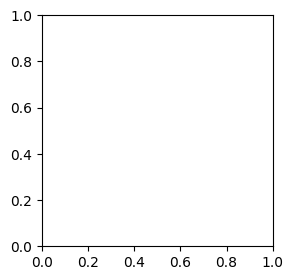

In [264]:
generate_raster_thumbnail(
    asset_id=asset_id,
    style_info=style_info,
    output_path= raster_thumbnail_path 
)

In [241]:
root_catalog = pystac.Catalog(
    id="PANindia",
    title="STAC Catalog for PAN India",
    description="STAC items for PAN india."
)
root_catalog.add_item(raster_item)

print("STAC Item and Catalog created successfully!")
print("STAC Item ID:", raster_item.id)
print("Item's Parent Catalog:", raster_item.get_parent().id)

STAC Item and Catalog created successfully!
STAC Item ID: Landscape-Restoration-WRI
Item's Parent Catalog: PANindia


In [238]:
output_dir = '../data/'


root_catalog.save(
    dest_href=output_dir,
    catalog_type=pystac.CatalogType.SELF_CONTAINED
)

ValueError: <Item id=Landscape-Restoration-WRI> does not have a self_href set.